In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
m = pd.read_csv('matches.csv')
d = pd.read_csv('deliveries.csv')

In [18]:
tw_mw = m[m['toss_winner'] == m['winner']].shape[0] / m.shape[0]
m['season'] = m['season'].apply(lambda x: int(x.split('/')[1]) if '/' in str(x) else int(x))
print(f"Toss & Match Win Prob: {tw_mw:.2%}")

Toss & Match Win Prob: 50.59%


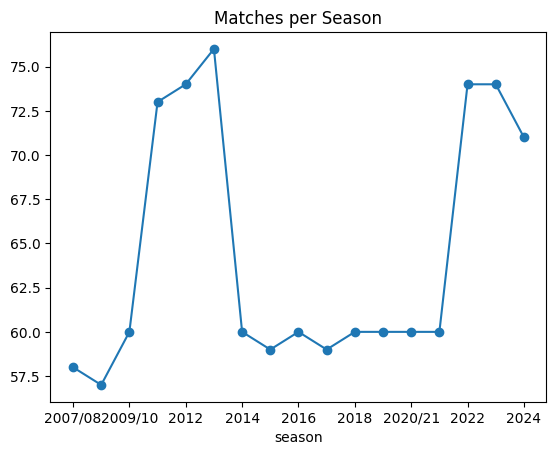

In [4]:
m['season'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title('Matches per Season')
plt.show()

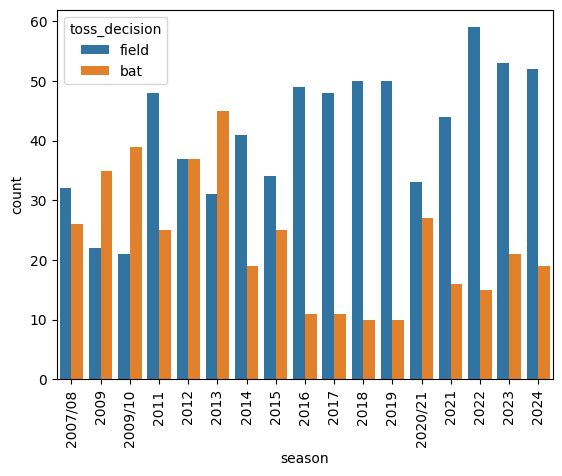

In [5]:
sns.countplot(x='season', hue='toss_decision', data=m)
plt.xticks(rotation=90)
plt.show()

In [6]:
runs = d.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)
print("Top Scorers:\n", runs)

Top Scorers:
 batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


In [7]:
wkts = d[d['is_wicket'] == 1].groupby('bowler').size().sort_values(ascending=False).head(10)
print("Top Wicket Takers:\n", wkts)

Top Wicket Takers:
 bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
dtype: int64


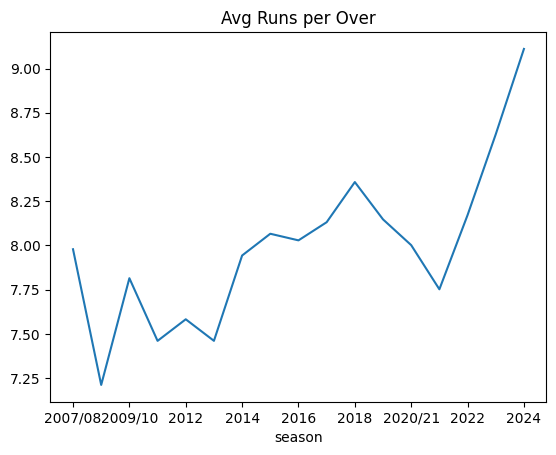

In [8]:
df_m = pd.merge(d, m[['id', 'season']], left_on='match_id', right_on='id')
avg_r = df_m.groupby('season')['total_runs'].sum() / (df_m.groupby('season').size() / 6)
avg_r.plot(title='Avg Runs per Over')
plt.show()

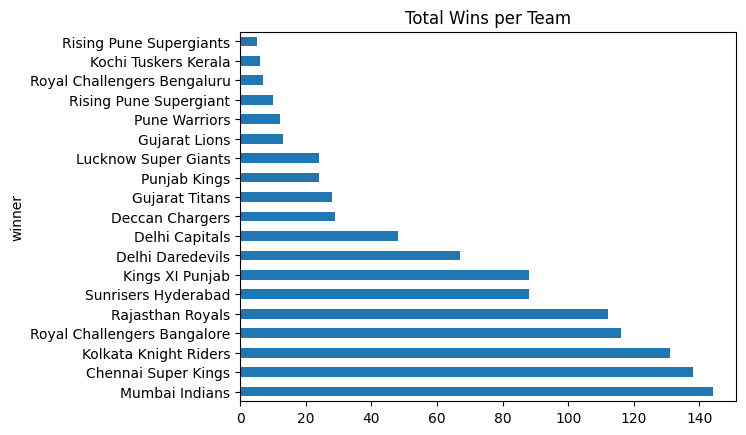

In [9]:
m['winner'].value_counts().plot(kind='barh')
plt.title('Total Wins per Team')
plt.show()

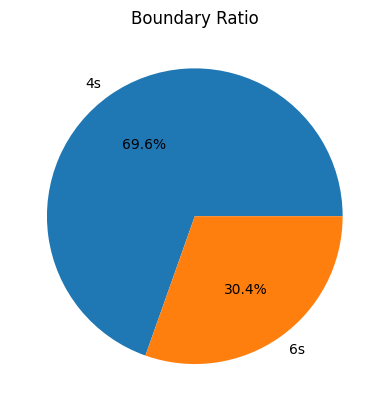

In [10]:
fours = d[d['batsman_runs'] == 4].shape[0]
sixes = d[d['batsman_runs'] == 6].shape[0]
plt.pie([fours, sixes], labels=['4s', '6s'], autopct='%1.1f%%')
plt.title('Boundary Ratio')
plt.show()

Top 10 High-Scoring Venues (ML Feature: Venue Avg):
 venue
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam    232.500000
Himachal Pradesh Cricket Association Stadium, Dharamsala              203.000000
Arun Jaitley Stadium, Delhi                                           200.062500
M Chinnaswamy Stadium, Bengaluru                                      197.214286
Eden Gardens, Kolkata                                                 196.625000
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh      191.200000
Rajiv Gandhi International Stadium, Uppal, Hyderabad                  189.384615
Brabourne Stadium                                                     181.400000
Barsapara Cricket Stadium, Guwahati                                   181.000000
Sawai Mansingh Stadium, Jaipur                                        180.500000
Name: target_runs, dtype: float64


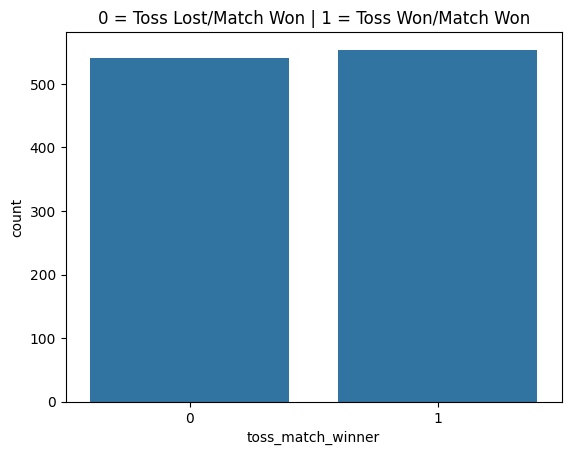

In [21]:

m['is_dl'] = m['method'].apply(lambda x: 1 if x == 'D/L' else 0)

# 2. SQL-Style Logic: Venue Dominance (Feature for ML)
# Checking which venues are 'high-scoring' vs 'low-scoring'
v_stats = m.groupby('venue')['target_runs'].mean().sort_values(ascending=False).head(10)
print("Top 10 High-Scoring Venues (ML Feature: Venue Avg):\n", v_stats)

# 3. ML Feature Engineering: Toss Influence
# Does winning the toss correlate with the result?
m['toss_match_winner'] = (m['toss_winner'] == m['winner']).astype(int)
sns.countplot(x='toss_match_winner', data=m)
plt.title('0 = Toss Lost/Match Won | 1 = Toss Won/Match Won')
plt.show()

# 4. Correlation Map (Fixed for 2024 Columns)
# We select numeric columns only for the heatmap


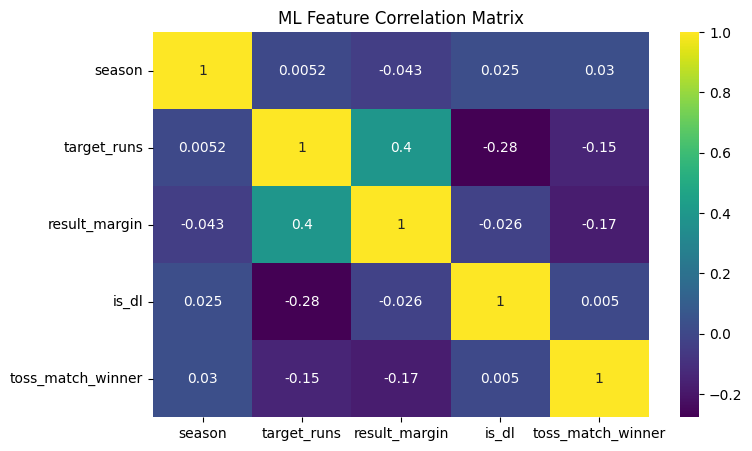

Missing Values per Column:
 id                      0
season                  0
city                   51
date                    0
match_type              0
player_of_match         5
venue                   0
team1                   0
team2                   0
toss_winner             0
toss_decision           0
winner                  5
result                  0
result_margin          19
target_runs             3
target_overs            3
super_over              0
method               1074
umpire1                 0
umpire2                 0
is_dl                   0
toss_match_winner       0
dtype: int64


In [20]:
cols = ['season', 'target_runs', 'result_margin', 'is_dl', 'toss_match_winner']
plt.figure(figsize=(8, 5))
sns.heatmap(m[cols].corr(), annot=True, cmap='viridis')
plt.title("ML Feature Correlation Matrix")
plt.show()

# 5. Data Quality Check (Crucial for ML Pre-processing)
print("Missing Values per Column:\n", m.isnull().sum())